# Neural Network Model-Based Recommender (Neural Collaborative Filtering)

This notebook trains a neural-network-based recommender (Neural Collaborative Filtering) on MovieLens 100K using PyTorch. It includes:

- data loading and per-user train/test split
- PyTorch Dataset/DataLoader
- NCF model (user & item embeddings + MLP)
- training loop with MSE loss
- evaluation: RMSE/MAE and Top-N Precision@K / Recall@K
- plots for training loss and metrics

If PyTorch is not installed, the notebook will attempt to install it (CPU-only). Run cells top-to-bottom in Jupyter.

In [4]:
# 1. Setup: imports and configuration
import sys, os, math, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

# Try importing torch; if not installed, install CPU-only torch
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print('PyTorch not available. The next cell will install a CPU-only build if running in an environment with pip.')

# Config
DATA_URL = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
DATA_DIR = Path('./ml-100k')
RATING_FILE = DATA_DIR / 'u.data'
TEST_FRAC = 0.2
EMBED_DIM = 32
MLP_LAYERS = [64,32,16]
LR = 1e-3
BATCH_SIZE = 1024
EPOCHS = 8
TOPN = 10
SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() and TORCH_AVAILABLE else 'cpu' if TORCH_AVAILABLE else 'cpu'
np.random.seed(SEED)

print('DEVICE =', DEVICE)


DEVICE = cpu


In [5]:
# Install PyTorch (CPU-only) if missing. This may take a minute.
import sys
if not 'torch' in sys.modules:
    try:
        print('Installing torch...')
        # CPU-only install via pip. In some environments an appropriate wheel is needed.
        !pip install --quiet torch torchvision --index-url https://download.pytorch.org/whl/cpu
        import torch
        import torch.nn as nn
        import torch.optim as optim
        from torch.utils.data import Dataset, DataLoader
        print('Installed torch version', torch.__version__)
    except Exception as e:
        print('Could not install torch automatically. Please install PyTorch manually and re-run the notebook.')
        raise
else:
    print('torch already available')


torch already available


In [6]:
# 2. Download MovieLens 100K if missing, and load ratings
import zipfile, urllib.request
if not DATA_DIR.exists() or not RATING_FILE.exists():
    print('Downloading MovieLens 100K...')
    zip_path = Path('ml-100k.zip')
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    zip_path.unlink()
    print('Downloaded and extracted MovieLens 100K')
else:
    print('Dataset present at', DATA_DIR)

cols = ['user_id','item_id','rating','timestamp']
ratings = pd.read_csv(RATING_FILE, sep='\t', names=cols, engine='python')
ratings = ratings.drop(columns=['timestamp'])
ratings['user'] = 'u' + ratings['user_id'].astype(str)
ratings['item'] = 'i' + ratings['item_id'].astype(str)
ratings = ratings[['user','item','rating']]
print('Loaded', len(ratings), 'ratings')


Dataset present at ml-100k
Loaded 100000 ratings


In [7]:
# 3. Train-test split per user
np.random.seed(SEED)

def train_test_split_per_user(df, test_frac=TEST_FRAC, seed=SEED):
    np.random.seed(seed)
    train_list=[]
    test_list=[]
    for u,g in df.groupby('user'):
        g_shuf = g.sample(frac=1.0, random_state=seed)
        n=len(g_shuf)
        if n==0: continue
        test_n = max(1, int(np.floor(n*test_frac)))
        test_list.append(g_shuf.iloc[:test_n])
        if n-test_n>0:
            train_list.append(g_shuf.iloc[test_n:])
    train_df = pd.concat(train_list).reset_index(drop=True)
    test_df = pd.concat(test_list).reset_index(drop=True)
    return train_df, test_df

train_df, test_df = train_test_split_per_user(ratings)
print('Train:', len(train_df), 'Test:', len(test_df))


Train: 80367 Test: 19633


In [8]:
# 4. Build user/item mappings and PyTorch Dataset
all_users = sorted(ratings['user'].unique())
all_items = sorted(ratings['item'].unique())
user_to_idx = {u:i for i,u in enumerate(all_users)}
item_to_idx = {it:i for i,it in enumerate(all_items)}
idx_to_user = {i:u for u,i in user_to_idx.items()}
idx_to_item = {i:it for it,i in item_to_idx.items()}

train_df['u_idx'] = train_df['user'].map(user_to_idx).astype(int)
train_df['i_idx'] = train_df['item'].map(item_to_idx).astype(int)

test_df['u_idx'] = test_df['user'].map(user_to_idx).astype(int)
test_df['i_idx'] = test_df['item'].map(item_to_idx).astype(int)

import torch
from torch.utils.data import Dataset, DataLoader

class RatingsDataset(Dataset):
    def __init__(self, df):
        self.u = torch.tensor(df['u_idx'].values, dtype=torch.long)
        self.i = torch.tensor(df['i_idx'].values, dtype=torch.long)
        self.r = torch.tensor(df['rating'].values, dtype=torch.float32)
    def __len__(self):
        return len(self.r)
    def __getitem__(self, idx):
        return self.u[idx], self.i[idx], self.r[idx]

train_ds = RatingsDataset(train_df)
test_ds = RatingsDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

n_users = len(all_users)
n_items = len(all_items)
print('n_users', n_users, 'n_items', n_items, 'train batches', len(train_loader))


n_users 943 n_items 1682 train batches 79


In [9]:
# 5. Define Neural Collaborative Filtering model (GMF + MLP merged)
import torch.nn as nn

class NCF(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=32, mlp_layers=[64,32,16]):
        super().__init__()
        # Embeddings
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        # MLP on concatenated embeddings
        mlp_layers_full = []
        input_dim = emb_dim * 2
        for h in mlp_layers:
            mlp_layers_full.append(nn.Linear(input_dim, h))
            mlp_layers_full.append(nn.ReLU())
            mlp_layers_full.append(nn.BatchNorm1d(h))
            input_dim = h
        self.mlp = nn.Sequential(*mlp_layers_full)
        # Final prediction layer
        self.out = nn.Linear(input_dim, 1)
        # init
        self._init_weights()
    def _init_weights(self):
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
        nn.init.kaiming_uniform_(self.out.weight, a=1)
    def forward(self, u, i):
        u_e = self.user_emb(u)
        i_e = self.item_emb(i)
        x = torch.cat([u_e, i_e], dim=-1)
        x = self.mlp(x)
        out = self.out(x).squeeze(-1)
        return out

# create model
import torch
model = NCF(n_users, n_items, emb_dim=EMBED_DIM, mlp_layers=MLP_LAYERS).to(DEVICE)
print(model)


NCF(
  (user_emb): Embedding(943, 32)
  (item_emb): Embedding(1682, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (out): Linear(in_features=16, out_features=1, bias=True)
)


In [10]:
# 6. Training loop
import torch.optim as optim
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    n_batches = 0
    for bu, bi, br in train_loader:
        bu = bu.to(DEVICE); bi = bi.to(DEVICE); br = br.to(DEVICE)
        optimizer.zero_grad()
        preds = model(bu, bi)
        loss = criterion(preds, br)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        n_batches += 1
    avg_loss = running_loss / max(1, n_batches)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch}/{EPOCHS} Train MSE loss: {avg_loss:.4f}')


Epoch 1/8 Train MSE loss: 13.6705
Epoch 2/8 Train MSE loss: 9.7702
Epoch 3/8 Train MSE loss: 5.2247
Epoch 4/8 Train MSE loss: 2.0688
Epoch 5/8 Train MSE loss: 0.9137
Epoch 6/8 Train MSE loss: 0.6824
Epoch 7/8 Train MSE loss: 0.6332
Epoch 8/8 Train MSE loss: 0.6011


In [11]:
# 7. Evaluate on test set (RMSE, MAE)
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(loader, model):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for bu, bi, br in loader:
            bu = bu.to(DEVICE); bi = bi.to(DEVICE)
            preds = model(bu, bi).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(br.numpy().tolist())
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'rmse': rmse, 'mae': mae, 'n': len(y_true)}

train_eval = evaluate_model(train_loader, model)
test_eval = evaluate_model(test_loader, model)
print('Train:', train_eval)
print('Test:', test_eval)


Train: {'rmse': 0.7162034925589817, 'mae': 0.5561479402040553, 'n': 80367}
Test: {'rmse': 1.0211888144034154, 'mae': 0.8026169861776389, 'n': 19633}


In [12]:
# 8. Top-N evaluation (Precision@K, Recall@K) - batched scoring for speed
# Precompute user->train seen set
from collections import defaultdict
user_seen = defaultdict(set)
for _, row in train_df.iterrows():
    user_seen[row.u_idx].add(row.i_idx)

# Function to recommend top-n items for a user by scoring all items using model
@torch.no_grad()
def recommend_top_n_for_user(model, user_idx, top_n=TOPN, exclude_seen=True, batch_size=1024):
    model.eval()
    device = next(model.parameters()).device
    u = torch.tensor([user_idx], dtype=torch.long, device=device)
    # repeat user for all items in batches
    scores = []
    item_indices = np.arange(n_items)
    for start in range(0, n_items, batch_size):
        end = min(n_items, start+batch_size)
        bi = torch.tensor(item_indices[start:end], dtype=torch.long, device=device)
        bu = u.repeat(len(bi))
        preds = model(bu, bi).cpu().numpy()
        scores.append(preds)
    scores = np.concatenate(scores)
    # apply mask for seen
    candidates = item_indices
    if exclude_seen:
        mask = np.array([idx not in user_seen[user_idx] for idx in candidates])
        candidates = candidates[mask]
        scores = scores[mask]
    top_idx_local = np.argsort(scores)[-top_n:][::-1]
    return [int(candidates[i]) for i in top_idx_local]

# Precision/Recall evaluation
def precision_recall_at_k_model(model, test_df, top_n=TOPN):
    precisions = []
    recalls = []
    users_eval = 0
    test_per_user = defaultdict(list)
    for _, row in test_df.iterrows():
        test_per_user[row.u_idx].append(row.i_idx)
    for u, true_list in test_per_user.items():
        true_set = set(true_list)
        recs = recommend_top_n_for_user(model, u, top_n=top_n)
        hit = len(set(recs) & true_set)
        precisions.append(hit / top_n)
        recalls.append(hit / len(true_set))
        users_eval += 1
    return {'precision': float(np.mean(precisions) if precisions else 0.0),
            'recall': float(np.mean(recalls) if recalls else 0.0),
            'users_eval': users_eval}

pr = precision_recall_at_k_model(model, test_df, top_n=TOPN)
print('Precision@%d = %.4f, Recall@%d = %.4f (users=%d)' % (TOPN, pr['precision'], TOPN, pr['recall'], pr['users_eval']))


Precision@10 = 0.0245, Recall@10 = 0.0116 (users=943)


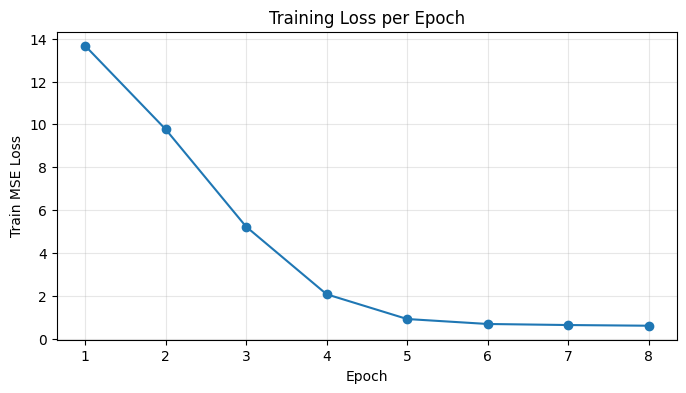

Final evaluations:
Train: {'rmse': 0.7162034925589817, 'mae': 0.5561479402040553, 'n': 80367}
Test: {'rmse': 1.0211888144034154, 'mae': 0.8026169861776389, 'n': 19633}
Precision/Recall@10: {'precision': 0.02449628844114528, 'recall': 0.0115741311166005, 'users_eval': 943}


In [13]:
# 9. Plots
plt.figure(figsize=(8,4))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Train MSE Loss')
plt.title('Training Loss per Epoch')
plt.grid(alpha=0.3)
plt.show()

print('Final evaluations:')
print('Train:', train_eval)
print('Test:', test_eval)
print('Precision/Recall@%d:' % TOPN, pr)


In [15]:
# 10. Save model and evaluation summaries
import pickle, json
out_dir = Path('./nn_model_based_movielens')
out_dir.mkdir(parents=True, exist_ok=True)
# Move model to cpu before saving
cpu_model = model.to('cpu')
with open(out_dir / 'ncf_model.pt', 'wb') as f:
    torch.save(cpu_model.state_dict(), f)

summary = {'train_eval': train_eval, 'test_eval': test_eval, 'precision_recall': pr}
with open(out_dir / 'ncf_eval_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved model and summaries to', out_dir)

# Example recommendations
for u in range(3):
    recs = recommend_top_n_for_user(model.to(DEVICE), u, top_n=5)
    rec_items = [idx_to_item[idx] for idx in recs]
    print('User', idx_to_user[u], '->', rec_items)


Saved model and summaries to nn_model_based_movielens
User u1 -> ['i1449', 'i945', 'i814', 'i488', 'i1628']
User u10 -> ['i1642', 'i272', 'i1449', 'i251', 'i1450']
User u100 -> ['i306', 'i1450', 'i647', 'i1512', 'i603']
